In [10]:
pip install ucimlrepo

In [11]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [12]:
adult

{'data': {'ids': None,
  'features':        age         workclass  fnlwgt  education  education-num  \
  0       39         State-gov   77516  Bachelors             13   
  1       50  Self-emp-not-inc   83311  Bachelors             13   
  2       38           Private  215646    HS-grad              9   
  3       53           Private  234721       11th              7   
  4       28           Private  338409  Bachelors             13   
  ...    ...               ...     ...        ...            ...   
  48837   39           Private  215419  Bachelors             13   
  48838   64               NaN  321403    HS-grad              9   
  48839   38           Private  374983  Bachelors             13   
  48840   44           Private   83891  Bachelors             13   
  48841   35      Self-emp-inc  182148  Bachelors             13   
  
             marital-status         occupation    relationship  \
  0           Never-married       Adm-clerical   Not-in-family   
  1      Marri

In [13]:
X.isna().sum()

,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


In [14]:
y.isna().sum()

,0
income,0


In [15]:
X['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked',
       nan], dtype=object)

In [16]:
X['occupation'].unique()


array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', '?', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv', nan], dtype=object)

In [17]:
X['native-country'].unique()


array(['United-States', 'Cuba', 'Jamaica', 'India', '?', 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands', nan], dtype=object)

In [18]:
X.loc[:,'workclass']=X['workclass'].fillna(X['workclass'].mode()[0])
X.loc[:,'occupation']=X['occupation'].fillna(X['occupation'].mode()[0])
X.loc[:,'native-country']=X['native-country'].fillna(X['native-country'].mode()[0])

In [19]:
X.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


K-NN is a imputor now use knn as imputor

In [20]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

data = pd.DataFrame({
    'Age': [25,30,np.nan,40,35,np.nan,28],
    'salary': [50000,60000,55000,np.nan,65000,52000,np.nan],
    'Experience':[2,5,3,10,7,4,3]
})

print(data)

    Age   salary  Experience
0  25.0  50000.0           2
1  30.0  60000.0           5
2   NaN  55000.0           3
3  40.0      NaN          10
4  35.0  65000.0           7
5   NaN  52000.0           4
6  28.0      NaN           3


In [21]:
imputer = KNNImputer(n_neighbors=5)

imputed_array = imputer.fit_transform(data)

imputed_data = pd.DataFrame(imputed_array, columns=data.columns)

print(imputed_data)

    Age   salary  Experience
0  25.0  50000.0         2.0
1  30.0  60000.0         5.0
2  31.6  55000.0         3.0
3  40.0  56400.0        10.0
4  35.0  65000.0         7.0
5  31.6  52000.0         4.0
6  28.0  56400.0         3.0


In [22]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([10,50,55,57,70,75,76,78,80,100,120])

In [23]:
q1 = np.percentile(data,25)
q2 = np.percentile(data,50)
q3 = np.percentile(data,75)

print("Q1 :",q1)
print("Q2 :",q2)
print("Q3 :",q3)

IQR = q3-q1

print("IQR :",IQR)

Q1 : 56.0
Q2 : 75.0
Q3 : 79.0
IQR : 23.0


In [24]:
lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR
print("Lower Bound :",lower_bound)
print("Upper Bound :",upper_bound)

Lower Bound : 21.5
Upper Bound : 113.5


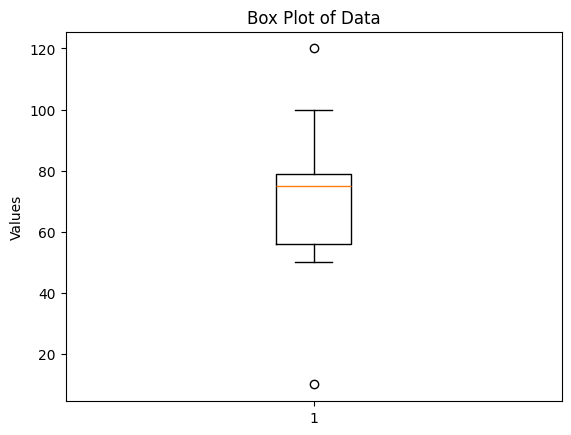

In [25]:
plt.figure()
plt.boxplot(data)
plt.title("Box Plot of Data")
plt.ylabel("Values")
plt.show()

In [26]:
import pandas as pd

data = {
    'customer':['Riya','Meena','Tejas','Divya','Paras'],
    'satisfaction':['Low','High','Medium','Very High','Low']
}

df = pd.DataFrame(data)

print(df)

  customer satisfaction
0     Riya          Low
1    Meena         High
2    Tejas       Medium
3    Divya    Very High
4    Paras          Low


In [27]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

df['Label_Encoded'] = label.fit_transform(df['satisfaction'])

print(df)

  customer satisfaction  Label_Encoded
0     Riya          Low              1
1    Meena         High              0
2    Tejas       Medium              2
3    Divya    Very High              3
4    Paras          Low              1


In [28]:
data = {
    'customer':['Riya','Meena','Tejas','Divya','Paras'],
    'gender':['Female','Female','Male','Female','Male']
}

dff = pd.DataFrame(data)

print(dff)

  customer  gender
0     Riya  Female
1    Meena  Female
2    Tejas    Male
3    Divya  Female
4    Paras    Male


In [29]:
dff['Label_Encoded'] = label.fit_transform(dff['gender'])

print(dff)

  customer  gender  Label_Encoded
0     Riya  Female              0
1    Meena  Female              0
2    Tejas    Male              1
3    Divya  Female              0
4    Paras    Male              1


In [30]:
from sklearn.preprocessing import OrdinalEncoder

rank = [['Low','Medium','High','Very High']]
order = OrdinalEncoder(categories=rank)

df['Order_Encoded'] = order.fit_transform(df[['satisfaction']]).astype(int)

print(df)

  customer satisfaction  Label_Encoded  Order_Encoded
0     Riya          Low              1              0
1    Meena         High              0              2
2    Tejas       Medium              2              1
3    Divya    Very High              3              3
4    Paras          Low              1              0


In [31]:
X =df['satisfaction']

user_encoded = pd.get_dummies(X).astype(int)
user_encoded

,High,Low,Medium,Very High
0,0,1,0,0
1,1,0,0,0
2,0,0,1,0
3,0,0,0,1
4,0,1,0,0


In [32]:
import pandas as pd

data = {
    'salary':[30000,50000,70000,200000],
    'experience':[2,5,7,10],
    'age':[25,30,35,60]
}

df = pd.DataFrame(data)

print(df)


   salary  experience  age
0   30000           2   25
1   50000           5   30
2   70000           7   35
3  200000          10   60


In [33]:
mins = df['salary'].min()
maxs = df['salary'].max()
mins
maxs

200000

In [34]:
mine = df['experience'].min()
maxe = df['experience'].max()
mine
maxe

10

In [35]:
min = df['age'].min()
max = df['age'].max()
min
max

60

In [36]:
from sklearn.preprocessing import MaxAbsScaler

maxabs_scale = MaxAbsScaler()

df_maxabs = pd.DataFrame(maxabs_scale.fit_transform(df),columns=df.columns)

print(df_maxabs)

   salary  experience       age
0    0.15         0.2  0.416667
1    0.25         0.5  0.500000
2    0.35         0.7  0.583333
3    1.00         1.0  1.000000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scale = MinMaxScaler()

df_minmax = pd.DataFrame(minmax_scale.fit_transform(df),columns=df.columns)

print(df_minmax)

     salary  experience       age
0  0.000000       0.000  0.000000
1  0.117647       0.375  0.142857
2  0.235294       0.625  0.285714
3  1.000000       1.000  1.000000


In [38]:
from sklearn.preprocessing import Normalizer

l2_normalizer = Normalizer(norm='l2')

df_l2 = pd.DataFrame(l2_normalizer.fit_transform(df),columns=df.columns)

print(df_l2)

l1_normalizer = Normalizer(norm='l1')

df_l1 = pd.DataFrame(l1_normalizer.fit_transform(df),columns=df.columns)

print(df_l1)

   salary  experience       age
0     1.0    0.000067  0.000833
1     1.0    0.000100  0.000600
2     1.0    0.000100  0.000500
3     1.0    0.000050  0.000300
     salary  experience       age
0  0.999101    0.000067  0.000833
1  0.999300    0.000100  0.000600
2  0.999400    0.000100  0.000500
3  0.999650    0.000050  0.000300


In [39]:
from sklearn.preprocessing import StandardScaler

standard_scale = StandardScaler()

df_standard = pd.DataFrame(standard_scale.fit_transform(df),columns=df.columns)

print(df_standard)

     salary  experience       age
0 -0.865004   -1.371989 -0.928477
1 -0.564133   -0.342997 -0.557086
2 -0.263262    0.342997 -0.185695
3  1.692399    1.371989  1.671258


HW :- Preprocessing or feature engineering

1. Find dataset from UCIML that having numerical and string missing values and handle it with KNNimputer.

In [40]:
pip install ucimlrepo

In [41]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [42]:
X.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [43]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [44]:
df_encoded = pd.get_dummies(X, columns=X.columns)

In [45]:
imputer = KNNImputer(n_neighbors=5)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df_encoded),
    columns=df_encoded.columns
)

In [46]:
print(df_imputed.isnull().sum())

age_29      0
age_34      0
age_35      0
age_37      0
age_38      0
           ..
ca_2.0      0
ca_3.0      0
thal_3.0    0
thal_6.0    0
thal_7.0    0
Length: 397, dtype: int64


2. Find dataset from UCIML that having outliers. Find Method to find outliers from dataset rather than IQR.also handle outliers.

In [47]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [48]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [49]:
print(X)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free_sulfur_dioxide  

In [50]:
z_scores = np.abs(stats.zscore(X))

# Count total outliers
outliers = (z_scores > 3)

print("Total Outliers in each column:\n", np.sum(outliers))

Total Outliers in each column:
 541


In [51]:
outlier_rows = np.where(z_scores > 3)
print("Total rows with outliers:", len(set(outlier_rows[0])))

Total rows with outliers: 488


In [52]:
df_clean = X[(z_scores < 3).all(axis=1)]

print("Original Shape:", X.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (6497, 11)
After Removing Outliers: (6009, 11)


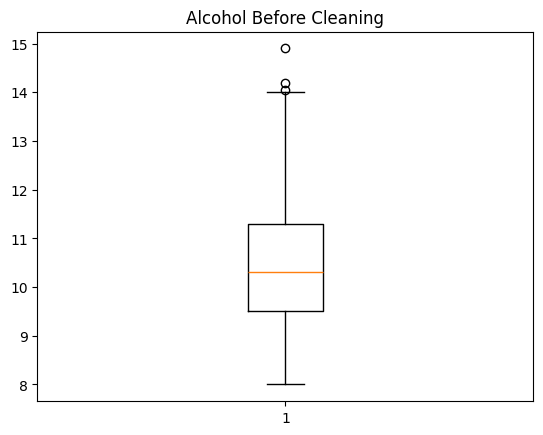

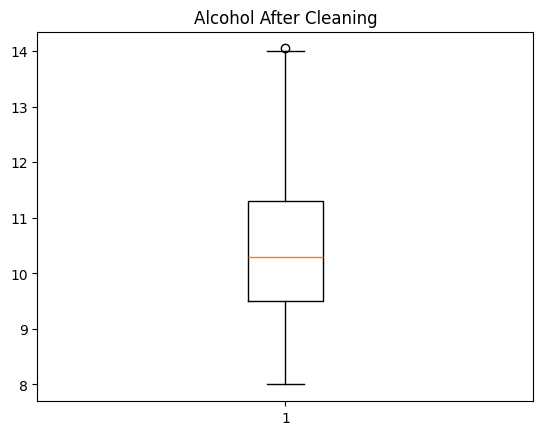

In [53]:
plt.boxplot(X['alcohol'])
plt.title("Alcohol Before Cleaning")
plt.show()

plt.boxplot(df_clean['alcohol'])
plt.title("Alcohol After Cleaning")
plt.show()